
This notebook performs binary classification using historical scada data, with alarm data used as the target label. The data is preprocessed, split into training and testing sets, and transformed into sequences for an LSTM model. The trained model is evaluated using performance metrics, and SHAP is applied to explain the model predictions.

The alarm tag that used here is (OGREY1_G1_KONTROLL_HURTIGSTOPP_MEK_AL) that is a combined alarm for several critical mechanical components belonging to Generator 1, and it requires the machine to stop immediately when this alarm is triggered.




In [ ]:
# We used google collab, so in order to load the dataset, we first need to mount the drive.
# import the google drive

from google.colab import drive
drive.mount('/content/drive')

import os
os.listdir('/content/drive/MyDrive/Binary_Alarm_Prediction/OGREY1_G1_KONTROLL_HURTIGSTOPP_MEK_AL')

Mounted at /content/drive


['cleaned_KONTROLL_HURTIGSTOPP_MEK_AL.csv',
 'Tag_HURTIGSTOPP_MEK_SMOTHE.ipynb',
 'Tag_HURTIGSTOPP_MEK_LSTM.ipynb',
 'cleaned_KONTROLL_HURTIGSTOPP_MEK_AL_edit.csv',
 'Tag_HURTIGSTOPP_MEK_LSTM_SHARP.ipynb']

In [ ]:
# import all the necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall, AUC
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
import shap





In [ ]:
# load the alarm log dataset
df_alarm= pd.read_csv('/content/drive/MyDrive/Binary_Alarm_Prediction/clean_alarmlogg/clean_alarm_data.csv')


In [ ]:
# load the historical data for alarm tag
df= pd.read_csv('/content/drive/MyDrive/Binary_Alarm_Prediction/OGREY1_G1_KONTROLL_HURTIGSTOPP_MEK_AL/cleaned_KONTROLL_HURTIGSTOPP_MEK_AL.csv',sep=",",dtype=str,engine="python")


In [ ]:
df_alarm.columns

Index(['ACK_TS', 'ALARMDESC', 'CATEGORY', 'id', 'TAG', 'ON_TS', 'OFF_TS'], dtype='object')

In [ ]:
df.columns

Index(['DateTime', 'REG_P_LAST(KW)', 'REG_NIVA_LAST(m)', 'REG_NIVA_PV(m)',
       'REG_P_PV(KW)', 'AGC_DB_SP'],
      dtype='object')

In [ ]:
#  Filter alarm records for the selected tag (2024–2025)

df_alarm["ACK_TS"] = pd.to_datetime(df_alarm["ACK_TS"])

df_filter_tag = df_alarm[
    (df_alarm["TAG"] == "OGREY1_G1_KONTROLL_HURTIGSTOPP_MEK_AL") &
    (df_alarm["ACK_TS"] >= "2024-01-01") &
    (df_alarm["ACK_TS"] < "2025-01-01")].copy()

In [ ]:
df_filter_tag.shape

(123, 7)

In [ ]:
# Convert ACK_TSto  datetime format
df_filter_tag["ACK_TS"] = pd.to_datetime(df_filter_tag["ACK_TS"])

# create a copy of historical dataset for further analysis
df_work=df.copy()

df_work["DateTime"] = pd.to_datetime(df_work["DateTime"])

#create a column Class in df_work dataset
df_work["Class"] = 0
alarm_times = df_filter_tag["ACK_TS"]
rounded_alarm=alarm_times.dt.floor("H")
df_work.loc[df_work["DateTime"].isin(rounded_alarm), "Class"] = 1


/tmp/ipykernel_1248/3295786427.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rounded_alarm=alarm_times.dt.floor("H")


In [ ]:
# Shows the historical dataset with extra column Calss
df_work.head(5)

,DateTime,REG_P_LAST(KW),REG_NIVA_LAST(m),REG_NIVA_PV(m),REG_P_PV(KW),AGC_DB_SP,Class
0,2023-12-31 23:00:00,8200.0,-0.5,-0.5,600.0,0.0,0
1,2024-01-01 00:00:00,8200.0,-0.5,-0.5,4264.748807683333,5.475555462666667,0
2,2024-01-01 01:00:00,8200.0,-0.5,-0.5,5600.0,5.599999905,0
3,2024-01-01 02:00:00,8200.0,-0.5,-0.5,5503.84444445,5.502222220116667,0
4,2024-01-01 03:00:00,8200.0,-0.5,-0.5,5500.0,5.5,0


In [ ]:
df_work.shape

(8785, 7)

In [ ]:
print(df_work['DateTime'].min())
print(df_work['DateTime'].max())

2023-12-31 23:00:00
2024-12-31 23:00:00


In [ ]:
# # Display the distribution of binary class labels (0 and 1)
df_work['Class'].value_counts()

,count
Class,
0,8670
1,115


In [ ]:
# Monthly distribution of binary classes (0 and 1)
df_work["DateTime"] = pd.to_datetime(df_work["DateTime"])
df_work["month"] = df_work["DateTime"].dt.to_period("M")
df_work.groupby("month")["Class"].value_counts().unstack(fill_value=0)

Class,0,1
month,,
2023-12,1,0
2024-01,739,5
2024-02,696,0
2024-03,743,1
2024-04,720,0
2024-05,743,1
2024-06,720,0
2024-07,739,5
2024-08,735,9


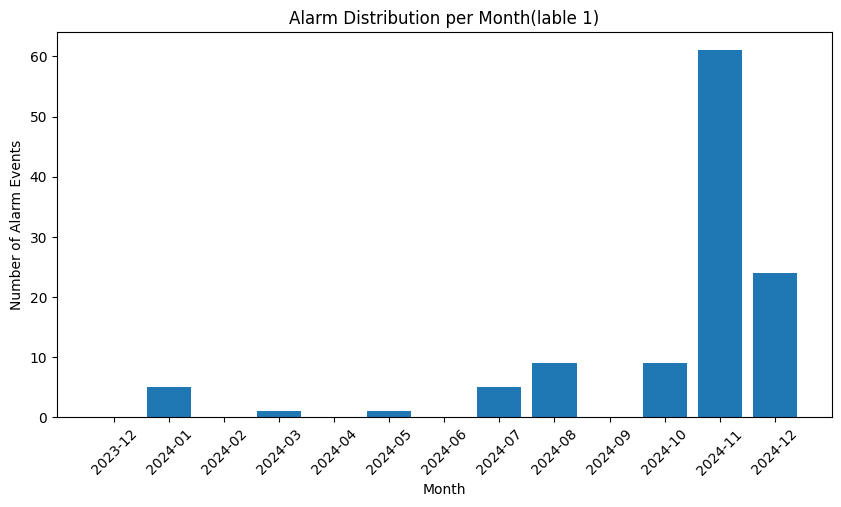

In [ ]:


# Count alarms per month
monthly_counts = df_work.groupby("month")["Class"].sum()

# Convert month format to string
monthly_counts.index = monthly_counts.index.astype(str)

# Bar plot
plt.figure(figsize=(10,5))
plt.bar(monthly_counts.index, monthly_counts.values)

plt.xlabel("Month")
plt.ylabel("Number of Alarm Events")
plt.title("Alarm Distribution per Month(lable 1)")

plt.xticks(rotation=45)
plt.show()


In [ ]:
## Separate the feature columns and the DateTime column for further processing
feature_cols = ['REG_P_LAST(KW)', 'REG_NIVA_LAST(m)', 'REG_NIVA_PV(m)', 'REG_P_PV(KW)', 'AGC_DB_SP']
df_work[feature_cols] = df_work[feature_cols].astype(str).apply(lambda col: col.str.strip().str.replace(",", ".", regex=False))
df_work[feature_cols] = df_work[feature_cols].apply(pd.to_numeric, errors="coerce")

### Correlation Analysis: The correlation matrix was computed to show the strength and direction of relationships between numerical features of dataset.
### Red indicates positive correlation, while blue indicates negative correlation

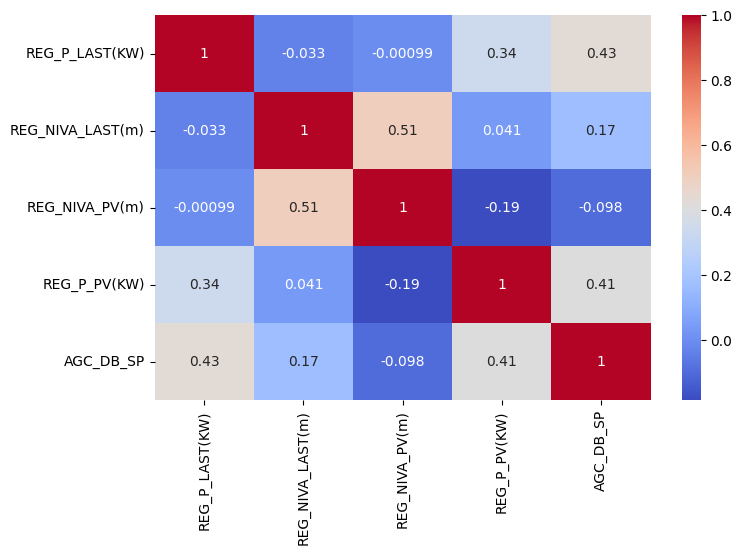

In [ ]:

corr = df_work[feature_cols].corr()
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()


In [ ]:
# Split the data into training and testing sets

split_date = "2024-11-30"

train = df_work[df_work["DateTime"] < split_date]
test  = df_work[df_work["DateTime"] >= split_date]

In [ ]:
# Apply feature scaling to the dataset

feature_cols = ['REG_P_LAST(KW)', 'REG_NIVA_LAST(m)', 'REG_NIVA_PV(m)', 'REG_P_PV(KW)', 'AGC_DB_SP']

scaler = StandardScaler() # compute Mean and SD
train[feature_cols] = scaler.fit_transform(train[feature_cols]) # Fit the scaler on the training set and transform the data
test[feature_cols] = scaler.transform(test[feature_cols])

/tmp/ipykernel_1248/438411872.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train[feature_cols] = scaler.fit_transform(train[feature_cols]) # Fit the scaler on the training set and transform the data
/tmp/ipykernel_1248/438411872.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test[feature_cols] = scaler.transform(test[feature_cols])


### **Create sequences using a sliding window for LSTM input**




In [ ]:
# Create LSTM sequences using a sliding window of 24 timesteps

window = 24

def make_sequences(df_work, feature_cols, target_col="Class", window=24):
    X, y = [], []  # Empty lists to store inputs and targets
    values = df_work[feature_cols].values  # Get feature data as numpy array
    alarms = df_work[target_col].values     # Get target(class 0/1) as numpy array

    for i in range(len(df_work) - window):
        X.append(values[i:i+window])
        y.append(alarms[i+window])

    return np.array(X), np.array(y) # convert list to array and return

# Convert raw data into sequence format for LSTM training
X_train, y_train = make_sequences(train, feature_cols, "Class", window)
X_test, y_test = make_sequences(test, feature_cols, "Class", window)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(7993, 24, 5) (7993,)
(744, 24, 5) (744,)


In [ ]:
print("Train:")
print(pd.Series(y_train).value_counts())

print("Test:")
print(pd.Series(y_test).value_counts())

Train:
0    7904
1      89
Name: count, dtype: int64
Test:
0    720
1     24
Name: count, dtype: int64


### **Validation sets**

In [ ]:
# Divide the training data into train and validation sets

val_size = int(len(X_train) * 0.2)

X_val = X_train[-val_size:]
y_val = y_train[-val_size:]

X_train2 = X_train[:-val_size]
y_train2 = y_train[:-val_size]

## **Builds the model architecture (structure)**





In [ ]:

# Build the LSTM model architecture, shape 24 and 5(features )

model = Sequential([
    LSTM(64,input_shape=(24, 5)),
    Dropout(0.2),

    BatchNormalization(),

    Dense(32, activation="relu"),
    Dropout(0.2),


    Dense(1, activation="sigmoid")
])

# Compile the model with the optimizer, loss function, and metrics
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        Precision(name="precision"),
        Recall(name="recall"),
        AUC(name="auc")
 ]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,161 (78.75 KB)

 Non-trainable params: 128 (512.00 B)

## **Train the model on the training data**
###Training results may vary slightly between runs due to dropout and random weight initialization.

In [ ]:

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

class_weight = {0: 1, 1:35}
history = model.fit(
    X_train2, y_train2,
    validation_data=(X_val, y_val),
    epochs=50,         # number of training cycles
    batch_size=32,      # Number of samples processed at once
    callbacks=[early_stop],
    class_weight=class_weight,
    shuffle=False
)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9822 - auc: 0.9335 - loss: 0.1873 - precision: 0.0948 - recall: 0.5500 - val_accuracy: 0.9562 - val_auc: 0.6114 - val_loss: 0.2636 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9848 - auc: 0.8958 - loss: 0.2048 - precision: 0.1111 - recall: 0.5500 - val_accuracy: 0.9243 - val_auc: 0.5419 - val_loss: 0.3338 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9822 - auc: 0.8882 - loss: 0.2148 - precision: 0.1017 - recall: 0.6000 - val_accuracy: 0.8855 - val_auc: 0.6186 - val_loss: 0.3848 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9866 - auc: 0.9320 - loss: 0.1647 - precision: 0.1333 - recall: 0.6000 - val_accuracy: 0.8498 - val_auc: 0.5900 - val_loss: 0.7678 - val_precision: 0.0114 - val_recall: 0.0290
Epoc

##**Final evaluation**

In [ ]:
model.evaluate(X_test, y_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9664 - auc: 0.5939 - loss: 0.2979 - precision: 0.3333 - recall: 0.0417


[0.29786792397499084,
 0.9663978219032288,
 0.3333333432674408,
 0.0416666679084301,
 0.5939236879348755]

In [ ]:

# Predict probabilities once
y_prob = model.predict(X_test)

# Test different classification thresholds
for t in [0.001, 0.003, 0.005,0.01, 0.02, 0.03, 0.05]:
    print(f"\nThreshold: {t}")

    y_pred = (y_prob >= t).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("Precision:", round(precision, 3))
    print("Recall:", round(recall, 3))
    print("F1:", round(f1, 3))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Threshold: 0.001
[[336 384]
 [ 12  12]]
Precision: 0.03
Recall: 0.5
F1: 0.057

Threshold: 0.003
[[480 240]
 [ 16   8]]
Precision: 0.032
Recall: 0.333
F1: 0.059

Threshold: 0.005
[[597 123]
 [ 16   8]]
Precision: 0.061
Recall: 0.333
F1: 0.103

Threshold: 0.01
[[647  73]
 [ 17   7]]
Precision: 0.087
Recall: 0.292
F1: 0.135

Threshold: 0.02
[[670  50]
 [ 17   7]]
Precision: 0.123
Recall: 0.292
F1: 0.173

Threshold: 0.03
[[679  41]
 [ 17   7]]
Precision: 0.146
Recall: 0.292
F1: 0.194

Threshold: 0.05
[[695  25]
 [ 22   2]]
Precision: 0.074
Recall: 0.083
F1: 0.078


In [ ]:
print("Min:", y_prob.min())
print("Max:", y_prob.max())

Min: 4.5219856e-11
Max: 0.91953886


In [ ]:
print(np.percentile(y_prob, [50, 75, 90, 95, 99, 100]))

[0.00121236 0.00459073 0.01084511 0.0385534  0.25012299 0.91953886]


The AUC value indicates the model's ability to distinguish between the positive and negative classes. A higher AUC value reflects better classification performance:

AUC = 0.50         >> The model performs like random guessing

AUC = 0.70–0.80    >>  Acceptable performance

AUC = 0.80–0.90    >> Good performance.

AUC > 0.90         >> Excellent performance.

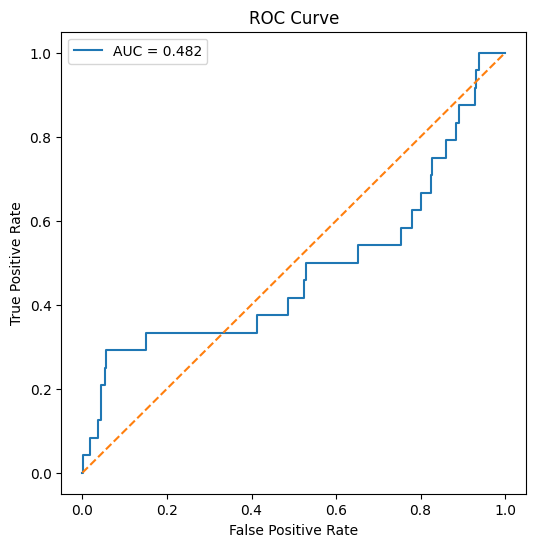

In [ ]:

# Compute ROC curve and AUC
#tpr (True Positive Rate), fpr (False Positive Rate)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

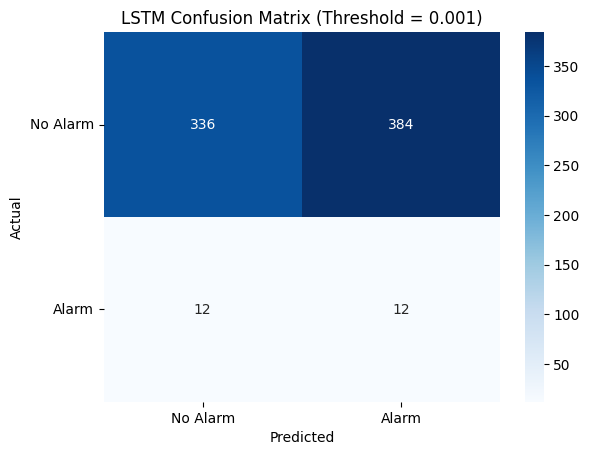

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([[336, 384],
               [12, 12]])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix (Threshold = 0.001)")

plt.xticks([0.5, 1.5], ['No Alarm', 'Alarm'])
plt.yticks([0.5, 1.5], ['No Alarm', 'Alarm'], rotation=0)

plt.show()

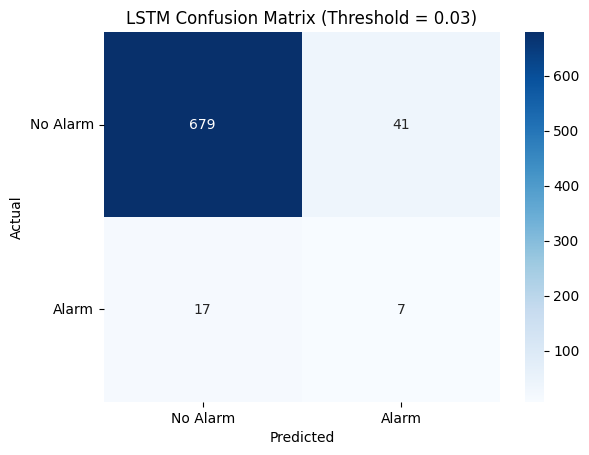

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm2 = np.array([[679, 41],
                [17, 7]])

sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix (Threshold = 0.03)")

plt.xticks([0.5, 1.5], ['No Alarm', 'Alarm'])
plt.yticks([0.5, 1.5], ['No Alarm', 'Alarm'], rotation=0)

plt.show()

In [ ]:
!pip install shap

**SHAP Analysis:**
Use SHAP to explain the LSTM model predictions and identify the most important features affecting the output.

In [ ]:
print("X_train2:", X_train2.shape)
print("X_test:", X_test.shape)
print("Features:", feature_cols)

X_train2: (6395, 24, 5)
X_test: (744, 24, 5)
Features: ['REG_P_LAST(KW)', 'REG_NIVA_LAST(m)', 'REG_NIVA_PV(m)', 'REG_P_PV(KW)', 'AGC_DB_SP']


In [ ]:
# Select a subset of training data as the SHAP background dataset
reference_sample = X_train2[:100]

# Select test samples to explain
X_explain = X_test[:50]

#Create a SHAP GradientExplainer for the trained LSTM model
explainer = shap.GradientExplainer(model, reference_sample)

#Compute SHAP values for the selected test samples
shap_values = explainer.shap_values(X_explain)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 24, 5))']
  warnings.warn(msg)


In [ ]:
if isinstance(shap_values, list):
    shap_values_array = shap_values[0]
else:
    shap_values_array = shap_values
print(shap_values_array.shape)

(50, 24, 5, 1)


In [ ]:
# removing the extra dimension
shap_values_array = np.squeeze(shap_values_array, axis=-1)

print(shap_values_array.shape)

(50, 24, 5)


In [ ]:
# Take absolute SHAP values (np.abs)
# Average them across all observations
# Get one importance score per feature
feature_importance = np.mean(np.abs(shap_values_array), axis=(0, 1))

for name, value in zip(feature_cols, feature_importance):
    print(name, value)

REG_P_LAST(KW) 0.00012996255857146367
REG_NIVA_LAST(m) 0.0009995268626463863
REG_NIVA_PV(m) 0.00030184504015778657
REG_P_PV(KW) 0.0028809440967112704
AGC_DB_SP 0.0016543875380739337


Global SHAP identifies the most important features by averaging SHAP values across all samples.

Higher mean SHAP values indicate greater feature importance.

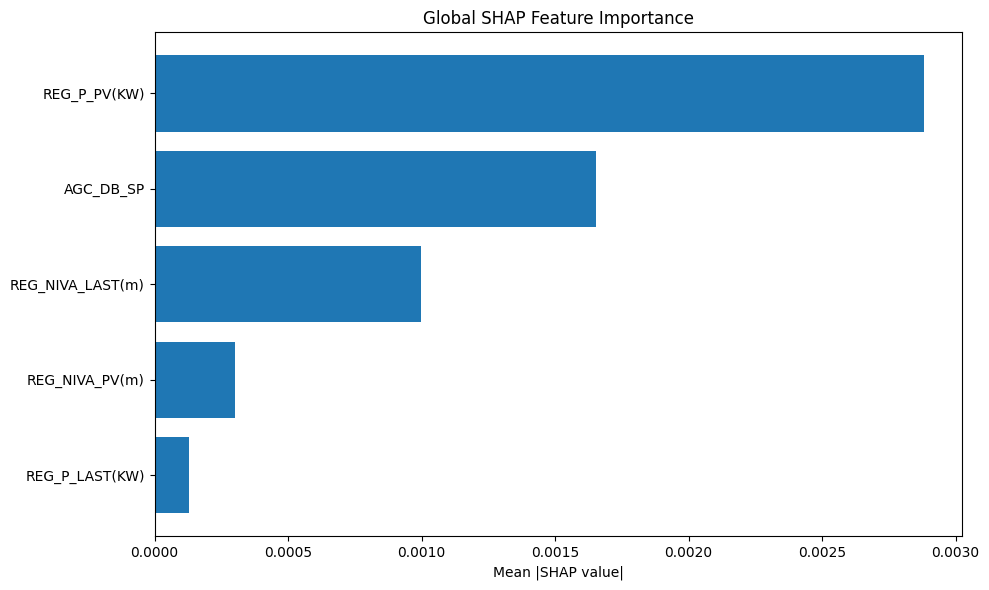

In [ ]:

importance_df = pd.DataFrame({"Feature": feature_cols, "Importance": feature_importance})

importance_df = importance_df.sort_values("Importance", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])

plt.xlabel("Mean |SHAP value|")
plt.title("Global SHAP Feature Importance")

plt.tight_layout()
plt.show()

SHAP Summary (beeswarm) Plot: Displays the impact of each feature on the model's predictions. Features are ranked by importance, and the color represents the feature value (blue = low, pink = high)

/tmp/ipykernel_1248/344949530.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_array.reshape(-1, 5),X_explain.reshape(-1, 5),feature_names=feature_cols)


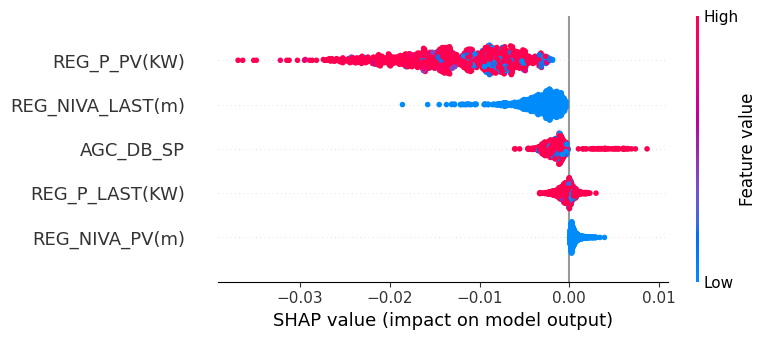

In [ ]:
shap.summary_plot(shap_values_array.reshape(-1, 5),X_explain.reshape(-1, 5),feature_names=feature_cols)